In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import datetime as dt

In [10]:
# 导入数据
customers = pd.read_csv("./raw_data/customers.csv")
orders = pd.read_csv("./raw_data/orders.csv")
order_items = pd.read_csv("./raw_data/order_items.csv")
order_payments = pd.read_csv("./raw_data/order_payments.csv")
products = pd.read_csv("./raw_data/products.csv")
reviews = pd.read_csv("./raw_data/reviews.csv")
sellers = pd.read_csv("./raw_data/sellers.csv")
category_translation = pd.read_csv("./raw_data/product_category_name_translation.csv")

print("数据导入完成")
print(f"customers: {customers.shape}")
print(f"orders: {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"order_payments: {order_payments.shape}")
print(f"products: {products.shape}")
print(f"reviews: {reviews.shape}")
print(f"sellers: {sellers.shape}")
print(f"category_translation: {category_translation.shape}")

数据导入完成
customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
products: (32951, 10)
reviews: (99224, 7)
sellers: (3095, 4)
category_translation: (71, 2)


## 一、研究假设与变量定义

为了系统评估订单评分的影响因素，本研究聚焦以下核心变量：

1. 订单总金额（order_total_amount）
2. 单商品平均金额（avg_amount_per_item）
3. 运费占比（freight_ratio）
4. 运费绝对值（order_total_freight）
5. 交货延迟天数（delivery_delay_days）
6. 是否迟到（is_delay）

后续将通过相关性分析与回归建模，验证各变量的影响方向与强度。

## 数据清洗与特征准备

In [11]:
# 转换日期格式（保留为 datetime，后续才能稳定使用 .dt）
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# 定义交货延迟（天）
# 交货延迟 = 实际交货日期 - 预计交货日期
# 负数表示提前送达，正数表示延迟送达
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

# 0/1 准时判断：准时或提前=0，延迟=1
orders["is_delay"] = np.where(
    orders["delivery_delay_days"].notna() & (orders["delivery_delay_days"] <= 0),
    0,
    1
)

orders[["order_delivered_customer_date", "order_estimated_delivery_date", "delivery_delay_days", "is_delay"]].head()

,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delay
0,2017-10-10 21:25:00,2017-10-18,-8.0,0
1,2018-08-07 15:27:00,2018-08-13,-6.0,0
2,2018-08-17 18:06:00,2018-09-04,-18.0,0
3,2017-12-02 00:28:00,2017-12-15,-13.0,0
4,2018-02-16 18:17:00,2018-02-26,-10.0,0


In [12]:
# 在 orders 中新增两列：订单总金额、订单单商品平均金额
order_amount_stats = (
    order_items.assign(item_amount=order_items["price"] + order_items["freight_value"])
    .groupby("order_id", as_index=False)
    .agg(
        order_total_amount=("item_amount", "sum"),
        order_item_count=("order_item_id", "count")
    )
)

order_amount_stats["avg_amount_per_item"] = (
    order_amount_stats["order_total_amount"] / order_amount_stats["order_item_count"]
)

orders = orders.merge(
    order_amount_stats[["order_id", "order_total_amount", "avg_amount_per_item"]],
    on="order_id",
    how="left"
)

# 保留两位小数
orders["order_total_amount"] = orders["order_total_amount"].round(2)
orders["avg_amount_per_item"] = orders["avg_amount_per_item"].round(2)

orders[["order_id", "order_total_amount", "avg_amount_per_item"]].head()

,order_id,order_total_amount,avg_amount_per_item
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,28.62


In [13]:
# 计算每一个订单运费占比
# 运费绝对值
# 运费占比 = 订单总运费 / 订单总金额

# 先按订单汇总总运费
order_freight_stats = (
    order_items.groupby("order_id", as_index=False)
    .agg(order_total_freight=("freight_value", "sum"))
)

# 合并到 orders
orders = orders.merge(order_freight_stats, on="order_id", how="left")

# 计算运费占比（避免除以0）
orders["freight_ratio"] = np.where(
    orders["order_total_amount"] > 0,
    orders["order_total_freight"] / orders["order_total_amount"],
    np.nan
)

orders[["order_id", "order_total_amount", "order_total_freight", "freight_ratio"]].head()

,order_id,order_total_amount,order_total_freight,freight_ratio
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,8.72,0.225265
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,22.76,0.160894
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,19.22,0.107302
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,27.20,0.376731
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,8.72,0.304682


## 1. 各变量与评分的相关性探索


与评分（order_review_score）的相关系数：
order_review_score     1.000000
avg_amount_per_item   -0.007762
freight_ratio         -0.026583
order_total_amount    -0.042076
order_total_freight   -0.089901
delivery_delay_days   -0.266990
is_delay              -0.392028
Name: order_review_score, dtype: float64


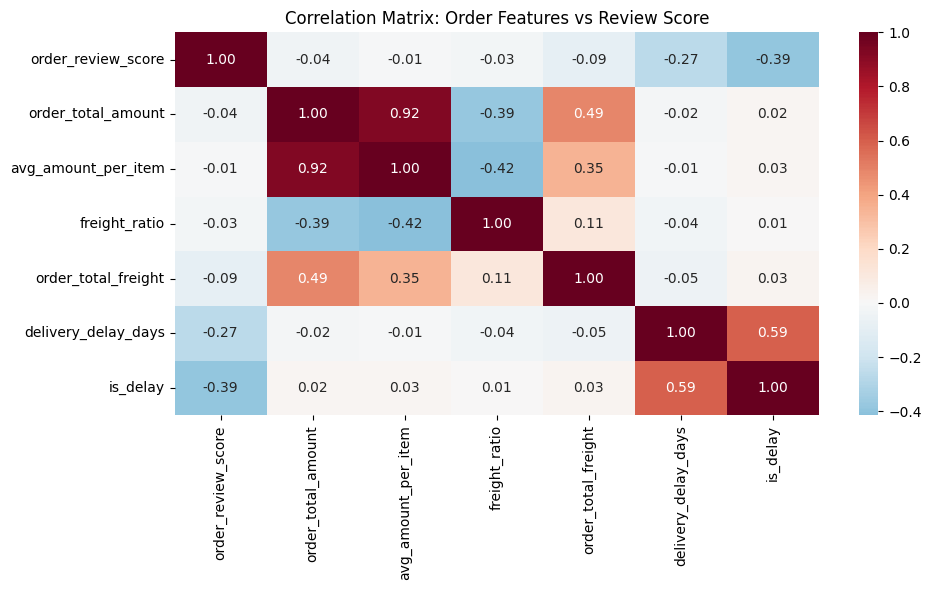

In [14]:
# 兼容不同评分字段命名
candidate_score_cols = ["review_score", "order_review_score", "review_rating"]
score_col = next((c for c in candidate_score_cols if c in reviews.columns), None)
if score_col is None:
    raise ValueError(f"reviews 中未找到评分列，当前列为: {list(reviews.columns)}")

# 一个订单可能有多条评价记录，先按订单聚合为平均评分
review_by_order = (
    reviews.groupby("order_id", as_index=False)
    .agg(order_review_score=(score_col, "mean"))
)

# 只合并分析所需字段
analysis_df = orders[[
    "order_id",
    "order_total_amount",
    "avg_amount_per_item",
    "freight_ratio",
    "order_total_freight",
    "delivery_delay_days",
    "is_delay",
]].merge(review_by_order, on="order_id", how="inner")

# 数值字段相关性
corr_cols = [
    "order_review_score",
    "order_total_amount",
    "avg_amount_per_item",
    "freight_ratio",
    "order_total_freight",
    "delivery_delay_days",
    "is_delay",
]
corr_df = analysis_df[corr_cols].dropna()
corr_matrix = corr_df.corr(numeric_only=True)

print("\n与评分（order_review_score）的相关系数：")
print(corr_matrix["order_review_score"].sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Matrix: Order Features vs Review Score")
plt.tight_layout()
plt.show()

### 小结：相关性分析结论

综合当前分析结果，可以得到以下结论：

- 订单是否迟到对评分影响最显著，与前期可视化结论一致。
- 交付时长与运费绝对值对评分也存在明显影响。
- 其他变量与评分之间的线性相关性相对较弱。

> 因此，后续建模将重点围绕送货时效与运费特征展开，以进一步识别其作用机制。

## 二、建模与评估

### 2.1 特征分布检视

#### 2.1.1 送货时效特征：是否迟到与迟到/提前天数

在初步可视化中可以看到：当订单准时送达时，评分与提前天数关系较弱；而当订单发生迟到时，随着迟到天数增加，评分呈明显下降趋势。

因此在建模时，将重点通过分段特征刻画这类非对称关系。

C:\Users\25003\AppData\Local\Temp\ipykernel_12432\1702373468.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_df, x="is_delay", ax=axes[0], palette="Set2")


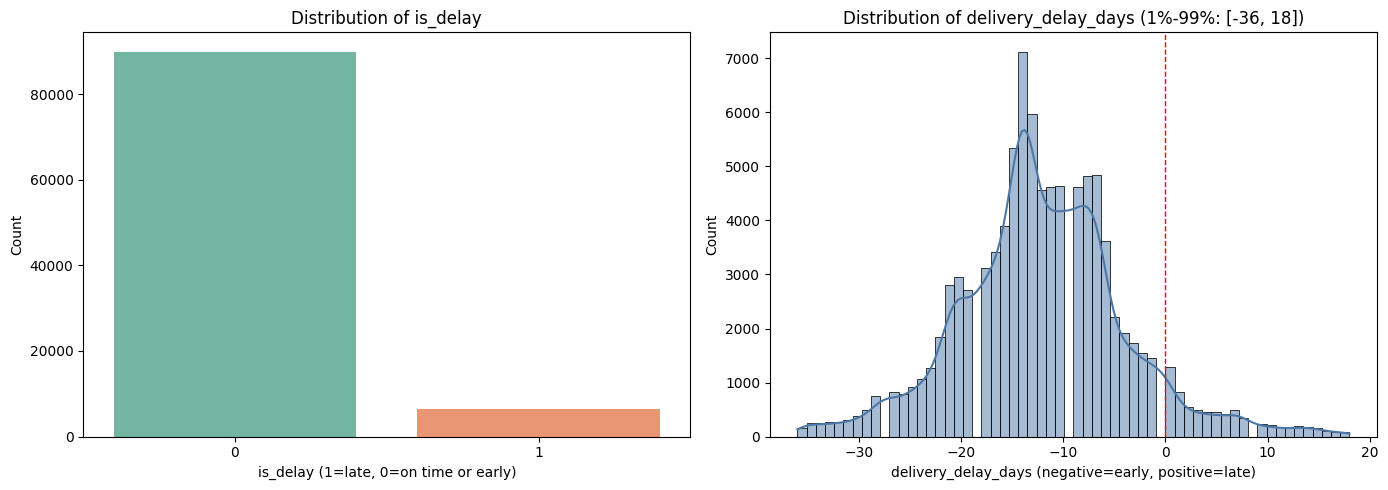

is_delay 占比：
is_delay
0    0.932263
1    0.067737
Name: proportion, dtype: float64

delivery_delay_days 描述统计：
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
1%         -36.000000
5%         -26.000000
50%        -12.000000
95%          3.000000
99%         18.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [15]:
# 查看“是否准时”与“迟到/提前天数”的分布
plot_df = orders[["is_delay", "delivery_delay_days"]].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 是否准时：类别分布
sns.countplot(data=plot_df, x="is_delay", ax=axes[0], palette="Set2")
axes[0].set_title("Distribution of is_delay")
axes[0].set_xlabel("is_delay (1=late, 0=on time or early)")
axes[0].set_ylabel("Count")

# 2) 迟到/提前天数：连续分布（截断极端值便于观察）
p01 = plot_df["delivery_delay_days"].quantile(0.01)
p99 = plot_df["delivery_delay_days"].quantile(0.99)
main_body = plot_df[
    (plot_df["delivery_delay_days"] >= p01) &
    (plot_df["delivery_delay_days"] <= p99)
]

sns.histplot(
    data=main_body,
    x="delivery_delay_days",
    bins=60,
    kde=True,
    ax=axes[1],
    color="#4C78A8"
)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title(f"Distribution of delivery_delay_days (1%-99%: [{p01:.0f}, {p99:.0f}])")
axes[1].set_xlabel("delivery_delay_days (negative=early, positive=late)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("is_delay 占比：")
print(plot_df["is_delay"].value_counts(normalize=True).sort_index())
print("\ndelivery_delay_days 描述统计：")
print(plot_df["delivery_delay_days"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

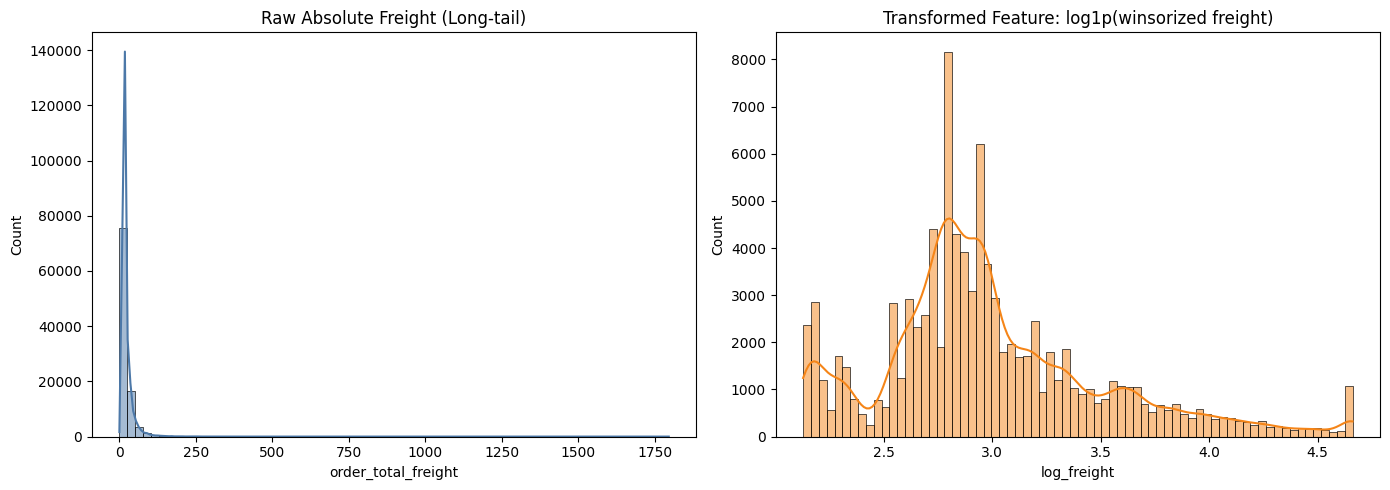

用于建模的运费特征统计：
       order_total_freight  freight_winsor   log_freight  freight_ratio
count         97917.000000    97917.000000  97917.000000   97917.000000
mean             22.804014       22.267347      2.990802       0.208835
std              21.621022       16.283987      0.516911       0.125734
min               0.000000        7.390000      2.127041       0.000000
1%                7.390000        7.390000      2.127041       0.024333
50%              17.160000       17.160000      2.899221       0.183256
95%              54.900000       54.900000      4.023564       0.456331
99%             104.795200      104.791168      4.661467       0.593772
max            1794.960000      104.795200      4.661505       0.955451

high_freight_flag 占比：
high_freight_flag
0    0.949968
1    0.050032
Name: proportion, dtype: float64


In [16]:
# 绝对运费特征工程实操：winsorize + log1p + high_freight_flag

# 1) 准备建模数据
if "analysis_df" in globals() and {"order_review_score", "order_total_freight", "freight_ratio"}.issubset(analysis_df.columns):
    model_df = analysis_df[["order_review_score", "order_total_freight", "freight_ratio"]].dropna().copy()
else:
    candidate_score_cols = ["review_score", "order_review_score", "review_rating"]
    score_col = next((c for c in candidate_score_cols if c in reviews.columns), None)
    if score_col is None:
        raise ValueError(f"reviews 中未找到评分列，当前列为: {list(reviews.columns)}")

    review_by_order = (
        reviews.groupby("order_id", as_index=False)
        .agg(order_review_score=(score_col, "mean"))
    )

    model_df = (
        orders[["order_id", "order_total_freight", "freight_ratio"]]
        .merge(review_by_order, on="order_id", how="inner")
        [["order_review_score", "order_total_freight", "freight_ratio"]]
        .dropna()
        .copy()
    )

# 2) 特征工程：截尾 + 对数 + 高运费标记
model_df = model_df[model_df["order_total_freight"] >= 0].copy()
q01 = model_df["order_total_freight"].quantile(0.01)
q95 = model_df["order_total_freight"].quantile(0.95)
q99 = model_df["order_total_freight"].quantile(0.99)

model_df["freight_winsor"] = model_df["order_total_freight"].clip(lower=q01, upper=q99)
model_df["log_freight"] = np.log1p(model_df["freight_winsor"])
model_df["high_freight_flag"] = (model_df["order_total_freight"] >= q95).astype(int)

# 3) 可视化：看变换效果与评分关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(model_df["order_total_freight"], bins=70, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Raw Absolute Freight (Long-tail)")
axes[0].set_xlabel("order_total_freight")
axes[0].set_ylabel("Count")

sns.histplot(model_df["log_freight"], bins=70, kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("Transformed Feature: log1p(winsorized freight)")
axes[1].set_xlabel("log_freight")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("用于建模的运费特征统计：")
print(model_df[["order_total_freight", "freight_winsor", "log_freight", "freight_ratio"]].describe(percentiles=[0.01, 0.5, 0.95, 0.99]))
print("\nhigh_freight_flag 占比：")
print(model_df["high_freight_flag"].value_counts(normalize=True).sort_index())

### 2.2 基线回归模型设定

为保证可解释性，最终模型同时纳入送货时间特征与运费特征。

a. 送货时间特征分解：

- late_days = max(delivery_delay_days, 0)
- early_days = max(-delivery_delay_days, 0)

b. 运费特征平滑处理：

- log_freight = log(1 + winsorize(order_total_freight))

基线模型形式为：

$$
\text{review\_score} = \beta_0 + \beta_1 \cdot \text{is\_delay} + \beta_2 \cdot \text{late\_days} + \beta_3 \cdot \text{early\_days} + \beta_4 \cdot \text{log\_freight}
$$

其中：

- $\beta_1$：迟到（相对准时/提前）带来的评分变化；
- $\beta_2$：每多迟到 1 天对评分的边际影响（预期为负）；
- $\beta_3$：每多提前 1 天对评分的边际影响（通常绝对值小于 $|\beta_2|$）；
- $\beta_4$：绝对运费（经对数变换后）的边际影响。

注意：delivery_delay_days 与 order_total_freight 在入模前均做 1%~99% 截尾。

### 2.3 模型训练与评估

In [17]:
# 按当前定稿方案训练基线模型
# review_score ~ is_delay + late_days + early_days + log_freight + bias

# 1) 评分字段兼容
candidate_score_cols = ["review_score", "order_review_score", "review_rating"]
score_col = next((c for c in candidate_score_cols if c in reviews.columns), None)
if score_col is None:
    raise ValueError(f"reviews 中未找到评分列，当前列为: {list(reviews.columns)}")

# 2) 评分
df_review = (
    reviews.groupby("order_id", as_index=False)
    .agg(order_review_score=(score_col, "mean"))
)

# 3) 合并建模数据
model_base = orders[["order_id", "delivery_delay_days", "is_delay", "order_total_freight"]].merge(
    df_review,
    on="order_id",
    how="inner"
)
model_base = model_base.dropna().copy()
model_base = model_base[model_base["order_total_freight"] >= 0].copy()

# 4) 按方案做截尾与特征构造（delivery_delay_days 与 freight 均做 1%~99% 截尾）
delay_p01 = model_base["delivery_delay_days"].quantile(0.01)
delay_p99 = model_base["delivery_delay_days"].quantile(0.99)
model_base["delay_winsor"] = model_base["delivery_delay_days"].clip(lower=delay_p01, upper=delay_p99)

freight_p01 = model_base["order_total_freight"].quantile(0.01)
freight_p99 = model_base["order_total_freight"].quantile(0.99)
model_base["freight_winsor"] = model_base["order_total_freight"].clip(lower=freight_p01, upper=freight_p99)
model_base["log_freight"] = np.log1p(model_base["freight_winsor"])

model_base["late_days"] = np.where(model_base["delay_winsor"] > 0, model_base["delay_winsor"], 0)
model_base["early_days"] = np.where(model_base["delay_winsor"] < 0, -model_base["delay_winsor"], 0)

feature_cols = ["is_delay", "late_days", "early_days", "log_freight"]
X = model_base[feature_cols]
y = model_base["order_review_score"]

# 5) 训练/测试集划分（按 is_delay 分层）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X["is_delay"]
)

# 6) 训练模型
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

# 7) 评估
def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

overall_rmse = rmse(y_test, y_pred)
overall_r2 = float(r2_score(y_test, y_pred))

print("=== Overall Test Metrics ===")
print(f"RMSE: {overall_rmse:.4f}")
print(f"R2  : {overall_r2:.4f}")

# 分组评估：迟到组 vs 非迟到组
test_eval = X_test.copy()
test_eval["y_true"] = y_test.values
test_eval["y_pred"] = y_pred

for g in [0, 1]:
    g_df = test_eval[test_eval["is_delay"] == g]
    if len(g_df) == 0:
        continue
    g_rmse = rmse(g_df["y_true"], g_df["y_pred"])
    g_r2 = float(r2_score(g_df["y_true"], g_df["y_pred"]))
    print(f"\n=== Group is_delay={g} ===")
    print(f"n   : {len(g_df)}")
    print(f"RMSE: {g_rmse:.4f}")
    print(f"R2  : {g_r2:.4f}")

# 系数解释输出
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": lr_model.coef_
}).sort_values("coef")

print("\n=== Coefficients (sorted) ===")
print(coef_df)
print(f"\nIntercept: {lr_model.intercept_:.4f}")

=== Overall Test Metrics ===
RMSE: 1.1607
R2  : 0.1847

=== Group is_delay=0 ===
n   : 17890
RMSE: 1.1361
R2  : 0.0113

=== Group is_delay=1 ===
n   : 1276
RMSE: 1.4631
R2  : 0.1189

=== Coefficients (sorted) ===
       feature      coef
0     is_delay -1.113204
3  log_freight -0.240218
1    late_days -0.093778
2   early_days  0.007717

Intercept: 4.9015


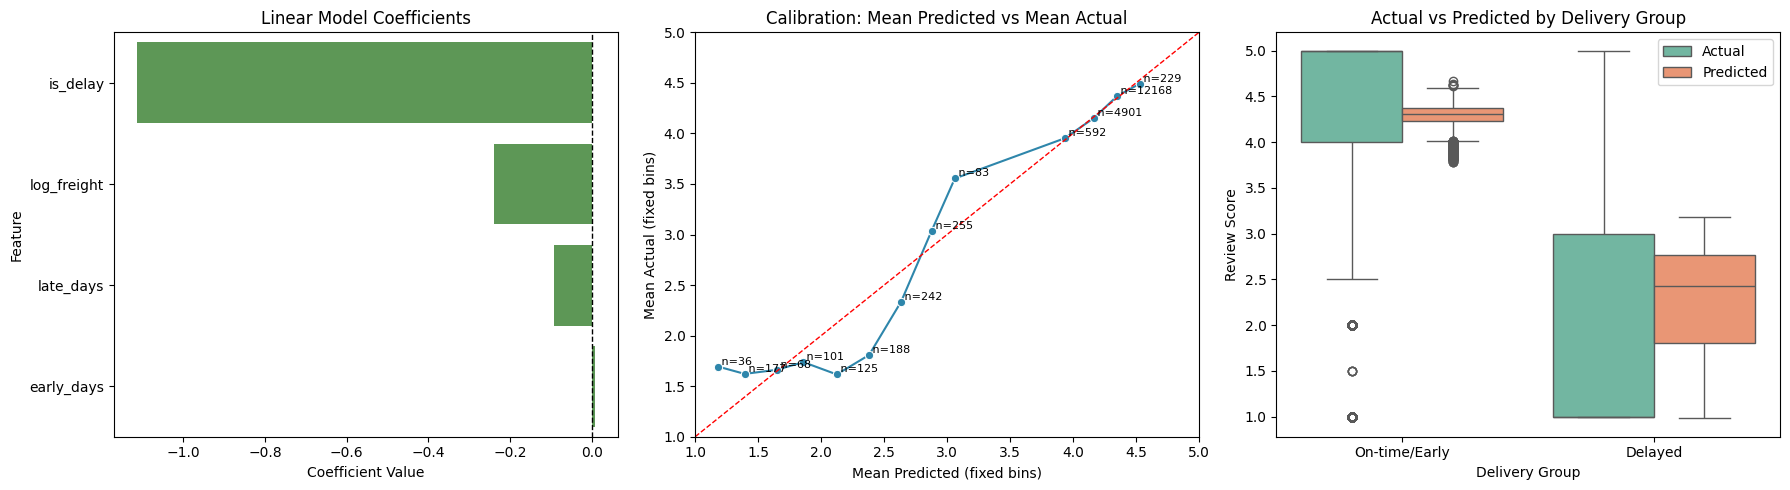

In [18]:
# 模型结果可视化：系数图 + 分箱校准图 + 分组箱线图

viz_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "is_delay": test_eval["is_delay"].values
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 模型系数图（保留）
coef_plot_df = coef_df.sort_values("coef")
sns.barplot(data=coef_plot_df, x="coef", y="feature", ax=axes[0], color="#54A24B")
axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Linear Model Coefficients")
axes[0].set_xlabel("Coefficient Value")
axes[0].set_ylabel("Feature")

# 2) 分箱校准图：预测均值 vs 真实均值（固定分箱，便于看 2~4 区间是否有样本）
calib_df = viz_df.copy()
fixed_bins = np.arange(1.0, 5.25, 0.25)
calib_df["pred_bin"] = pd.cut(
    calib_df["y_pred"],
    bins=fixed_bins,
    include_lowest=True,
    right=False
)
calib_summary = (
    calib_df.groupby("pred_bin", observed=False, as_index=False)
    .agg(
        pred_mean=("y_pred", "mean"),
        true_mean=("y_true", "mean"),
        n=("y_true", "size")
    )
)
calib_summary["bin_mid"] = calib_summary["pred_bin"].apply(lambda x: x.mid)

# 仅对有样本的箱画点；无样本箱会自然留空
valid = calib_summary["n"] > 0
sns.lineplot(
    data=calib_summary[valid],
    x="pred_mean",
    y="true_mean",
    marker="o",
    ax=axes[1],
    color="#2E86AB"
)
axes[1].plot([1, 5], [1, 5], linestyle="--", color="red", linewidth=1)
axes[1].set_xlim(1, 5)
axes[1].set_ylim(1, 5)
axes[1].set_title("Calibration: Mean Predicted vs Mean Actual")
axes[1].set_xlabel("Mean Predicted (fixed bins)")
axes[1].set_ylabel("Mean Actual (fixed bins)")

# 标注每个点的样本量
for _, r in calib_summary[valid].iterrows():
    axes[1].text(r["pred_mean"], r["true_mean"], f" n={int(r['n'])}", fontsize=8, va="bottom")

# 3) 按 is_delay 分组的真实/预测评分箱线图
box_df = pd.concat([
    viz_df[["is_delay", "y_true"]].rename(columns={"y_true": "score"}).assign(type="Actual"),
    viz_df[["is_delay", "y_pred"]].rename(columns={"y_pred": "score"}).assign(type="Predicted")
], ignore_index=True)
box_df["group"] = box_df["is_delay"].map({0: "On-time/Early", 1: "Delayed"})

sns.boxplot(data=box_df, x="group", y="score", hue="type", ax=axes[2], palette="Set2")
axes[2].set_title("Actual vs Predicted by Delivery Group")
axes[2].set_xlabel("Delivery Group")
axes[2].set_ylabel("Review Score")
axes[2].legend(title="")

plt.tight_layout()
plt.show()

## 三、结果分析与完整结论

### 3.1 关键发现

1. **送货时效是影响评分的首要因素**：`is_delay` 系数绝对值最大且为负，说明订单一旦迟到，用户评分会出现显著下滑。  
2. **迟到天数存在持续负向影响**：`late_days` 系数为负，迟到时间越长，评分进一步下降。  
3. **提前送达的边际收益较小**：`early_days` 系数接近 0，说明“提前”对评分提升有限，远弱于“迟到”的惩罚效应。  
4. **运费对评分存在负向影响**：`log_freight` 系数为负，说明在控制时效后，较高运费仍会压低用户评分。

### 3.2 业务建议

1. **优先降低迟到率**：相较于提前送达，避免迟到对提升用户评分更关键。可以在设置预计到达时间时增加安全边际，更进一步的，可以根据订单的实时运输情况动态调整预计到达时间，降低迟到风险。
2. **重点处理长迟到订单**：迟到天数的边际惩罚持续存在，应优先处理高风险履约链路。  
3. **适当控制运费**：在同等履约条件下，过高运费会带来额外评分损失，建议结合补贴、包邮门槛或运费透明化策略进行优化。

### 3.3 局限与后续改进

- 当前模型为线性基线模型，解释性强但对非线性关系和极端样本拟合有限。  
- 后续可考虑：  
  1. 引入交互项与非线性项（如 `is_delay × log_freight`、分段函数）；  
  2. 使用树模型（LightGBM/XGBoost）对比预测提升。

> **最终结论**：本研究验证了“履约时效主导评分、运费次级影响”的总体规律。若以提升用户评分为目标，最有效的策略是“先控迟到，再优化运费体验”。